# IMC Prosperity 4: Round 1 EDA

This notebook explores the price and trade execution data for Round 1 to find characteristics like spread, volume imbalances, and mean-reverting trends for `INTARIAN_PEPPER_ROOT` and `ASH_COATED_OSMIUM`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

plt.style.use('seaborn-v0_8-darkgrid')

## 1. Data Aggregation

In [2]:
base_path = '../ROUND1'

prices_files = glob.glob(os.path.join(base_path, 'prices_round_1_day_*.csv'))
trades_files = glob.glob(os.path.join(base_path, 'trades_round_1_day_*.csv'))

# Sort files to ensure chronological order: day -2, -1, 0
prices_files.sort(key=lambda x: int(os.path.basename(x).split('_')[-1].split('.')[0]))
trades_files.sort(key=lambda x: int(os.path.basename(x).split('_')[-1].split('.')[0]))

prices_list = []
for f in prices_files:
    df = pd.read_csv(f, sep=';')
    prices_list.append(df)
prices_df = pd.concat(prices_list, ignore_index=True)

trades_list = []
for f in trades_files:
    df = pd.read_csv(f, sep=';')
    day = int(os.path.basename(f).split('_')[-1].split('.')[0])
    df['day'] = day
    trades_list.append(df)
trades_df = pd.concat(trades_list, ignore_index=True)

# Create continuous time index (each day has timestamps 0 to 999900 in increments of 100)
prices_df['continuous_time'] = (prices_df['day'] + 2) * 1000000 + prices_df['timestamp']
trades_df['continuous_time'] = (trades_df['day'] + 2) * 1000000 + trades_df['timestamp']

print(f"Loaded {len(prices_df)} price rows and {len(trades_df)} trades.")

Loaded 60000 price rows and 2276 trades.


## 2. Correlation Analysis

Correlation matrix:


product,ASH_COATED_OSMIUM,INTARIAN_PEPPER_ROOT
product,,
ASH_COATED_OSMIUM,1.000000,0.006931
INTARIAN_PEPPER_ROOT,0.006931,1.000000


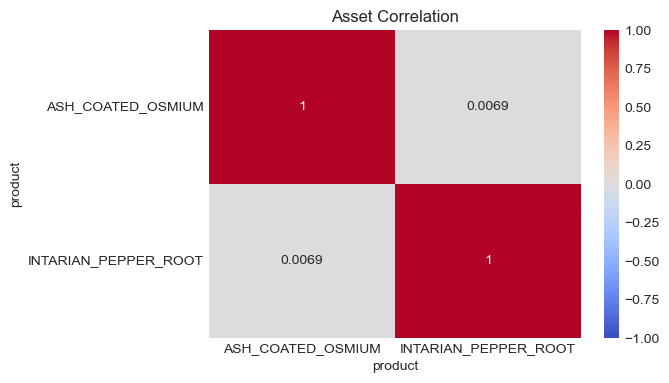

In [3]:
pivoted = prices_df.pivot(index='continuous_time', columns='product', values='mid_price')
corr = pivoted.corr()
print("Correlation matrix:")
display(corr)

# Plot correlation heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Asset Correlation')
plt.show()

## 3. Product-Specific Analysis: Price Trajectory, Spread, and Volume Imbalance


INTARIAN_PEPPER_ROOT EDA


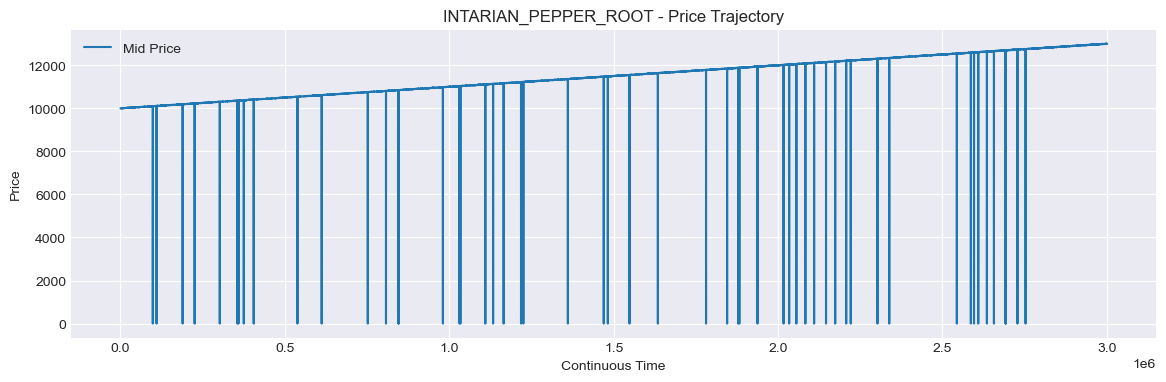

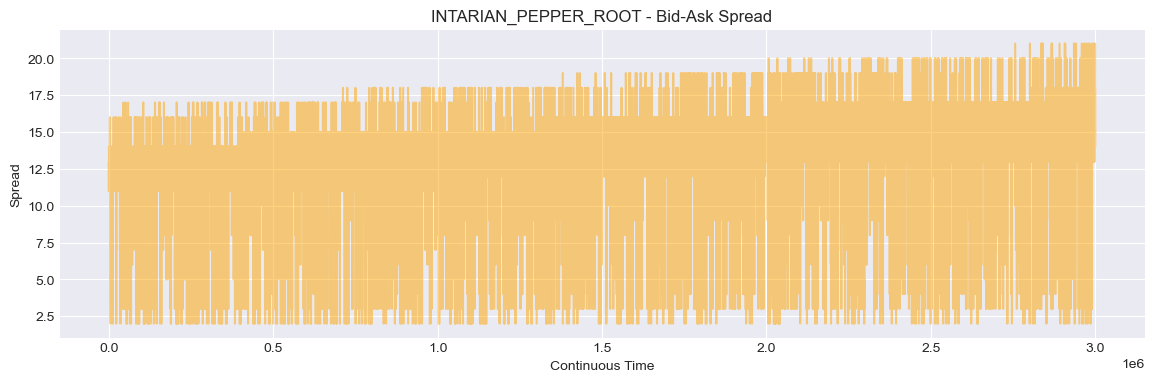

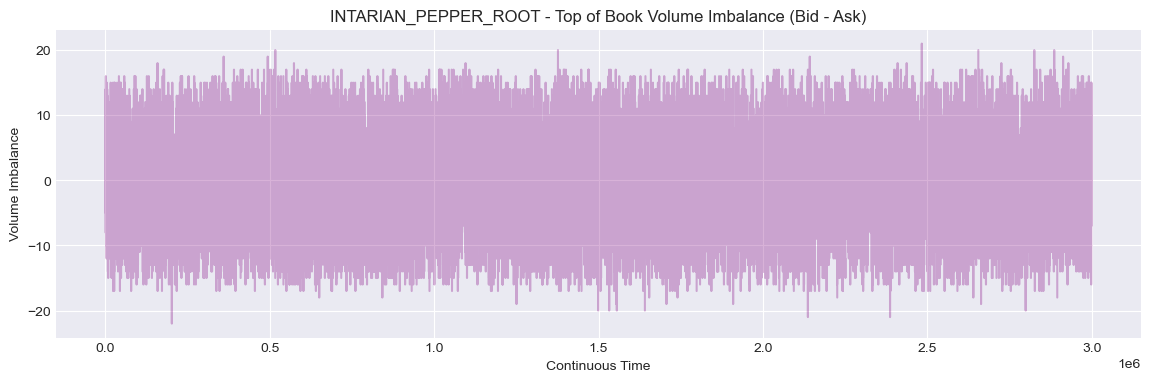

Statistics for INTARIAN_PEPPER_ROOT:
Average Spread: 13.05
Median Spread: 13.00
Volatility (std of mid_price): 993.18

ASH_COATED_OSMIUM EDA


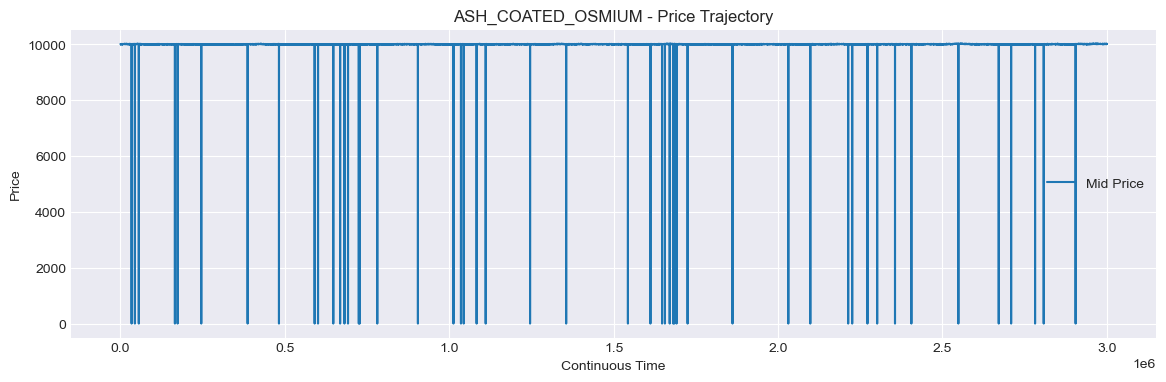

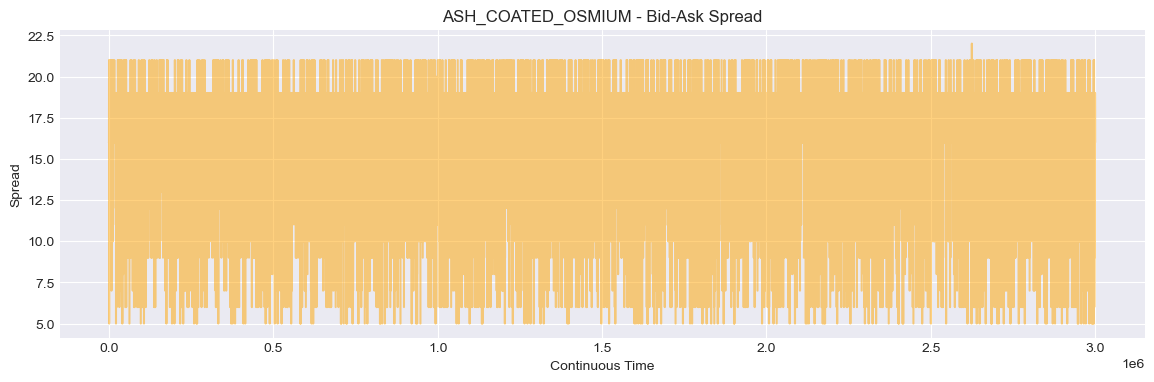

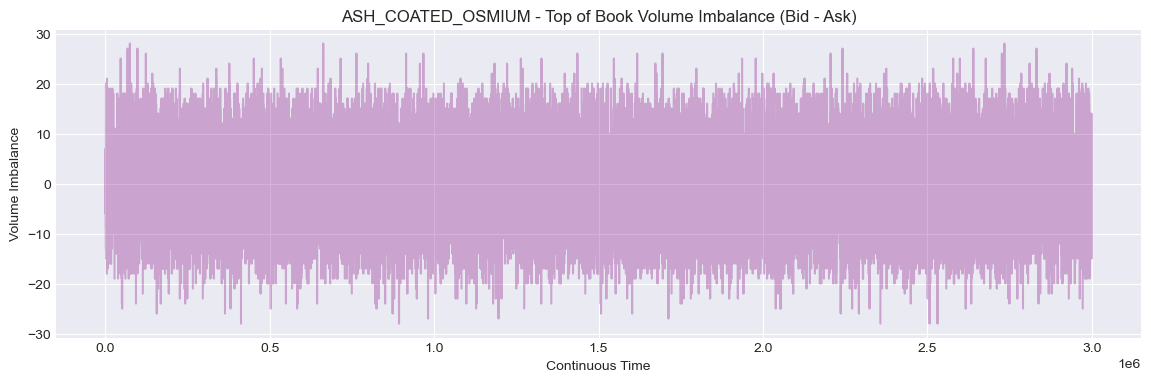

Statistics for ASH_COATED_OSMIUM:
Average Spread: 16.18
Median Spread: 16.00
Volatility (std of mid_price): 403.87


In [4]:
products = prices_df['product'].unique()

for product in products:
    prod_data = prices_df[prices_df['product'] == product].copy()
    
    print(f"\n{'='*50}")
    print(f"{product} EDA")
    print(f"{'='*50}")
    
    # 1. Price Trajectory
    plt.figure(figsize=(14, 4))
    plt.plot(prod_data['continuous_time'], prod_data['mid_price'], label='Mid Price')
    plt.title(f'{product} - Price Trajectory')
    plt.xlabel('Continuous Time')
    plt.ylabel('Price')
    plt.legend()
    plt.show()
    
    # 2. Spread Analysis
    prod_data['spread'] = prod_data['ask_price_1'] - prod_data['bid_price_1']
    plt.figure(figsize=(14, 4))
    plt.plot(prod_data['continuous_time'], prod_data['spread'], alpha=0.5, color='orange')
    plt.title(f'{product} - Bid-Ask Spread')
    plt.xlabel('Continuous Time')
    plt.ylabel('Spread')
    plt.show()
    
    # 3. Volume Imbalance
    prod_data['volume_imbalance'] = prod_data['bid_volume_1'] - prod_data['ask_volume_1']
    plt.figure(figsize=(14, 4))
    plt.plot(prod_data['continuous_time'], prod_data['volume_imbalance'], alpha=0.3, color='purple')
    plt.title(f'{product} - Top of Book Volume Imbalance (Bid - Ask)')
    plt.xlabel('Continuous Time')
    plt.ylabel('Volume Imbalance')
    plt.show()
    
    print(f"Statistics for {product}:")
    print(f"Average Spread: {prod_data['spread'].mean():.2f}")
    print(f"Median Spread: {prod_data['spread'].median():.2f}")
    print(f"Volatility (std of mid_price): {prod_data['mid_price'].std():.2f}")

## 4. Trade Execution Analysis


--- Trade Executions Summary ---


,mean,sum,count
symbol,,,
ASH_COATED_OSMIUM,5.211858,6593,1265
INTARIAN_PEPPER_ROOT,5.173096,5230,1011


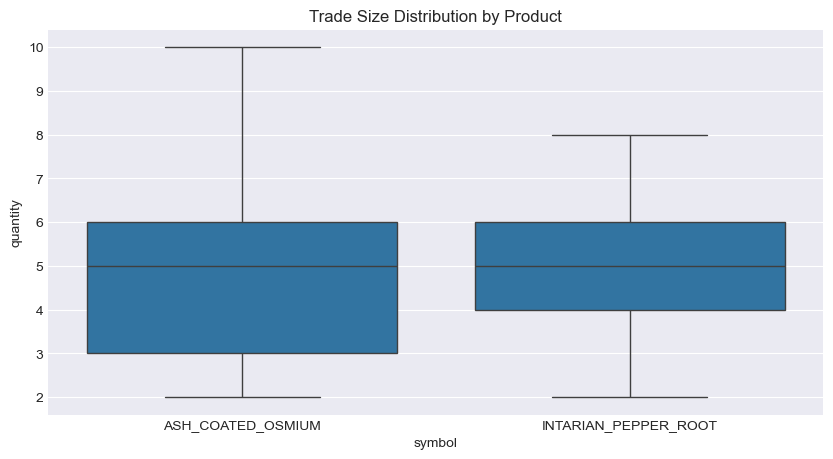

In [5]:
print("\n--- Trade Executions Summary ---")
summary = trades_df.groupby('symbol')['quantity'].agg(['mean', 'sum', 'count'])
display(summary)

plt.figure(figsize=(10, 5))
sns.boxplot(data=trades_df, x='symbol', y='quantity')
plt.title('Trade Size Distribution by Product')
plt.show()